In [1]:
# Install components if you are spinning up a clean runtime environment
!pip install --quiet opencv-python-headless paddleocr paddlepaddle matplotlib numpy pillow

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont
from paddleocr import PaddleOCR
import logging

# Mute verbose deep learning model loading logs
logging.getLogger("ppocr").setLevel(logging.ERROR)

In [3]:
def create_degraded_document() -> str:
    """Generates a degraded mock receipt image with rotation, noise, and low contrast."""
    # Create a base white image matrix
    base_img = np.ones((500, 600, 3), dtype=np.uint8) * 240
    pil_img = Image.fromarray(base_img)
    draw = ImageDraw.Draw(pil_img)

    # Draw mock invoice text lines
    draw.text((40, 50), "HEALTHCARE INC. REMITTANCE", fill=(40, 40, 40))
    draw.text((40, 100), "CLAIM NUMBER: CLM-991283", fill=(30, 30, 30))
    draw.text((40, 150), "Total Balance Due: $4,250.00", fill=(50, 50, 50))
    draw.text((40, 200), "Date: 2026-06-22", fill=(60, 60, 60))

    # Draw a mock outer border frame
    draw.rectangle([15, 15, 585, 485], outline=(100, 100, 100), width=4)

    # Convert back to openCV matrix array format
    cv_img = np.array(pil_img)

    # Degradation 1: Apply simulated high-frequency background noise
    noise = np.random.normal(0, 15, cv_img.shape).astype(np.int16)
    cv_img = np.clip(cv_img.astype(np.int16) + noise, 0, 255).astype(np.uint8)

    # Degradation 2: Induce deliberate geometric camera rotation (Skew)
    height, width = cv_img.shape[:2]
    center = (width // 2, height // 2)
    rotation_matrix = cv2.getRotationMatrix2D(center, angle=-4.5, scale=1.0)
    cv_img = cv2.warpAffine(cv_img, rotation_matrix, (width, height), borderValue=(220, 220, 220))

    # Save target messy image to system file cache
    output_path = "degraded_receipt.png"
    cv2.imwrite(output_path, cv_img)
    return output_path

# Execute generation
messy_doc_path = create_degraded_document()
print(f"Generated synthetic messy document file target at: '{messy_doc_path}'")

Generated synthetic messy document file target at: 'degraded_receipt.png'


In [4]:
class DocumentPreprocessor:
    """
    Production-grade image pipeline processing class designed to remove environmental
    noise and geometric skew distortions from document files.
    """

    @staticmethod
    def to_grayscale(img: np.ndarray) -> np.ndarray:
        """Removes channel dimensions. Improves downstream memory footprint speeds."""
        if len(img.shape) == 3:
            return cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        return img

    @staticmethod
    def enhance_contrast(img: np.ndarray) -> np.ndarray:
        """Applies Contrast Limited Adaptive Histogram Equalization (CLAHE)."""
        # Ensure image is single channel gray before running localized contrast adaptations
        gray = DocumentPreprocessor.to_grayscale(img)
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
        return clahe.apply(gray)

    @staticmethod
    def remove_noise(img: np.ndarray) -> np.ndarray:
        """Applies Median Blur filtering to eliminate pepper noise without degrading edges."""
        return cv2.medianBlur(img, 3)

    @staticmethod
    def binarize_threshold(img: np.ndarray) -> np.ndarray:
        """Converts grayscale arrays into strict binary black-and-white using Otsu's thresholding."""
        gray = DocumentPreprocessor.to_grayscale(img)
        # Otsu's threshold automatically calculates optimal separating value levels
        _, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
        return binary

    @staticmethod
    def correct_skew(img: np.ndarray) -> np.ndarray:
        """Detects text line variance orientation paths and rotates the canvas to align horizontally."""
        gray = DocumentPreprocessor.to_grayscale(img)
        # Invert colors so text is bright and background is dark for proper contour analysis
        inv_binary = cv2.bitwise_not(DocumentPreprocessor.binarize_threshold(gray))

        # Locate non-zero pixel coordinate arrays to find text boundaries
        coords = np.column_stack(np.where(inv_binary > 0))
        angle = cv2.minAreaRect(coords)[-1]

        # Adjust return bounding outputs based on orientation angle constraints
        if angle < -45:
            angle = -(90 + angle)
        else:
            angle = -angle

        # Rotate back around centroid
        height, width = img.shape[:2]
        center = (width // 2, height // 2)
        matrix = cv2.getRotationMatrix2D(center, angle, 1.0)
        return cv2.warpAffine(img, matrix, (width, height), flags=cv2.INTER_CUBIC, borderValue=255)

    @staticmethod
    def sharpen_edges(img: np.ndarray) -> np.ndarray:
        """Applies an unsharp mask kernel array configuration to maximize typeface contrast."""
        kernel = np.array([[0, -1, 0], [-1, 5, -1], [0, -1, 0]])
        return cv2.filter2D(img, -1, kernel)

    @staticmethod
    def remove_borders(img: np.ndarray) -> np.ndarray:
        """Crops out external scan border frames using bounding box envelope checks."""
        binary = DocumentPreprocessor.binarize_threshold(img)
        # Invert to isolate dark lines
        inv = cv2.bitwise_not(binary)
        contours, _ = cv2.findContours(inv, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        if contours:
            # Sort out components to identify the largest perimeter geometry grouping
            largest_contour = max(contours, key=cv2.contourArea)
            x, y, w, h = cv2.boundingRect(largest_contour)

            # Extract safe crop interior slice if region matches scale criteria
            if w > (img.shape[1] * 0.5) and h > (img.shape[0] * 0.5):
                return img[y:y+h, x:x+w]
        return img

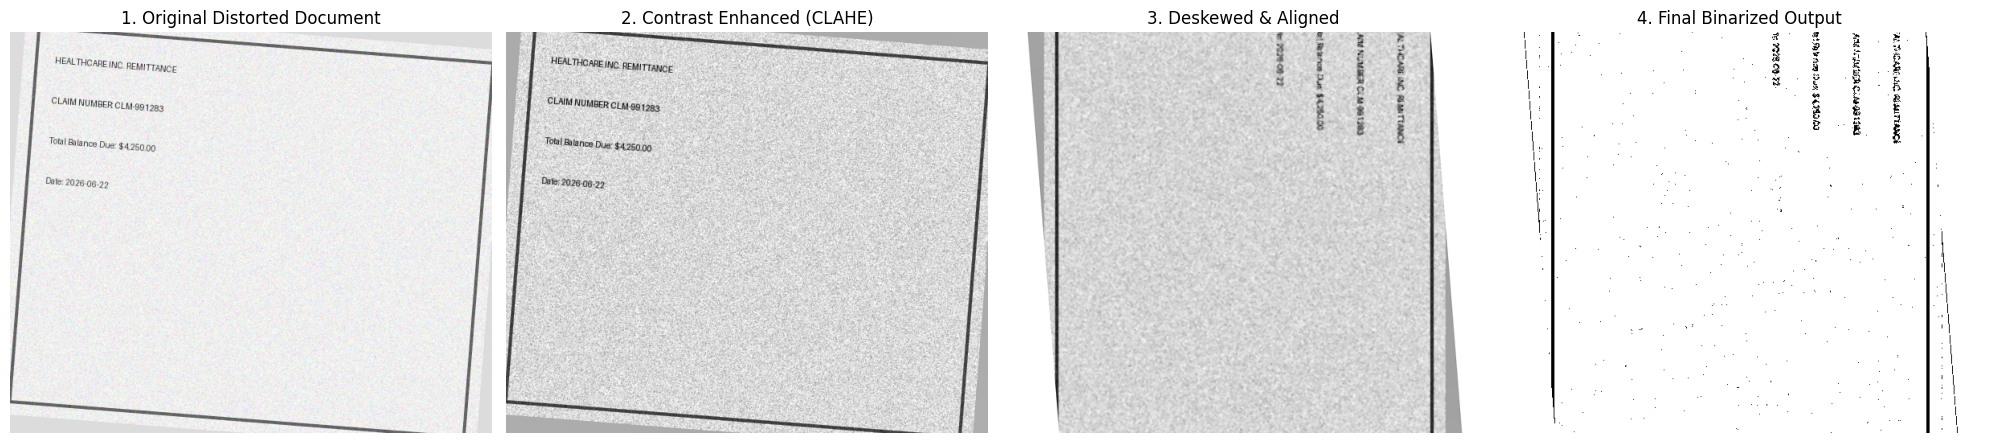

In [5]:
# Load original file using native OpenCV array decoders
raw_image = cv2.imread(messy_doc_path)

# Execute operations sequentially
step1_gray = DocumentPreprocessor.to_grayscale(raw_image)
step2_contrast = DocumentPreprocessor.enhance_contrast(step1_gray)
step3_denoise = DocumentPreprocessor.remove_noise(step2_contrast)
step4_skew = DocumentPreprocessor.correct_skew(step3_denoise)
step5_sharp = DocumentPreprocessor.sharpen_edges(step4_skew)
step6_crop = DocumentPreprocessor.remove_borders(step5_sharp)
final_clean_binary = DocumentPreprocessor.binarize_threshold(step6_crop)

# Plot intermediary pipelines
fig, axes = plt.subplots(1, 4, figsize=(20, 6))
axes[0].imshow(cv2.cvtColor(raw_image, cv2.COLOR_BGR2RGB))
axes[0].set_title("1. Original Distorted Document")
axes[0].axis('off')

axes[1].imshow(step2_contrast, cmap='gray')
axes[1].set_title("2. Contrast Enhanced (CLAHE)")
axes[1].axis('off')

axes[2].imshow(step4_skew, cmap='gray')
axes[2].set_title("3. Deskewed & Aligned")
axes[2].axis('off')

axes[3].imshow(final_clean_binary, cmap='gray')
axes[3].set_title("4. Final Binarized Output")
axes[3].axis('off')

plt.tight_layout()
plt.show()

In [8]:

import logging
import cv2
from paddleocr import PaddleOCR

# 1. Quiet the loggers
logging.getLogger("ppocr").setLevel(logging.ERROR)

# 2. Initialize the OCR engine
ocr_engine = PaddleOCR(
    use_textline_orientation=False,
    lang="en",
    enable_mkldnn=False
)

# --------------------------------------------------
# OCR on Raw Distorted Image
# --------------------------------------------------
print("--- Running OCR on Raw Distorted Image ---")

raw_result = ocr_engine.predict(messy_doc_path)

print("\nRaw OCR Result:")
print(raw_result)

raw_extracted_text = []

for res in raw_result:
    res_dict = res.to_dict() if hasattr(res, "to_dict") else res

    print("\nSingle OCR Result:")
    print(res_dict)

    texts = res_dict.get("rec_texts", [])
    raw_extracted_text.extend(texts)

# --------------------------------------------------
# Save cleaned image
# --------------------------------------------------
clean_image_path = "final_clean_document.png"
cv2.imwrite(clean_image_path, final_clean_binary)

# --------------------------------------------------
# OCR on Clean Image
# --------------------------------------------------
print("\n--- Running OCR on Preprocessed Clean Image ---")

if hasattr(ocr_engine, "model_instance") and hasattr(ocr_engine.model_instance, "model_settings"):
    ocr_engine.model_instance.model_settings["use_doc_preprocessor"] = False

clean_result = ocr_engine.predict(clean_image_path)

print("\nClean OCR Result:")
print(clean_result)

clean_extracted_text = []

for res in clean_result:
    res_dict = res.to_dict() if hasattr(res, "to_dict") else res

    print("\nSingle Clean OCR Result:")
    print(res_dict)

    texts = res_dict.get("rec_texts", [])
    clean_extracted_text.extend(texts)

# --------------------------------------------------
# Summary
# --------------------------------------------------
print("\n==========================================================")
print(f"Raw Text Extracted Count      : {len(raw_extracted_text)}")
print(f"Preprocessed Text Count       : {len(clean_extracted_text)}")
print("==========================================================")

print("\nRaw OCR Text:")
for line in raw_extracted_text:
    print("✓", line)

print("\nPreprocessed OCR Text:")
for line in clean_extracted_text:
    print("✓", line)

Creating model: ('PP-LCNet_x1_0_doc_ori', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/root/.paddlex/official_models/PP-LCNet_x1_0_doc_ori`.
Creating model: ('UVDoc', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/root/.paddlex/official_models/UVDoc`.
Creating model: ('PP-OCRv6_medium_det', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/root/.paddlex/official_models/PP-OCRv6_medium_det`.
Creating model: ('PP-OCRv6_medium_rec', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/root/.paddlex/official_models/PP-OCRv6_medium_rec`.


--- Running OCR on Raw Distorted Image ---

Raw OCR Result:
[{'input_path': 'degraded_receipt.png', 'page_index': None, 'doc_preprocessor_res': {'input_path': None, 'page_index': None, 'input_img': array([[[220, ..., 220],
        ...,
        [220, ..., 220]],

       ...,

       [[220, ..., 220],
        ...,
        [220, ..., 220]]], dtype=uint8), 'model_settings': {'use_doc_orientation_classify': True, 'use_doc_unwarping': True}, 'angle': 0, 'rot_img': array([[[220, ..., 220],
        ...,
        [220, ..., 220]],

       ...,

       [[220, ..., 220],
        ...,
        [220, ..., 220]]], dtype=uint8), 'output_img': array([[[244, ..., 233],
        ...,
        [239, ..., 243]],

       ...,

       [[227, ..., 244],
        ...,
        [241, ..., 240]]], dtype=uint8)}, 'dt_polys': [array([[14, 23],
       ...,
       [14, 40]], dtype=int16), array([[16, 77],
       ...,
       [16, 91]], dtype=int16), array([[ 16, 128],
       ...,
       [ 16, 144]], dtype=int16), array([[